In [1]:
from label_studio_sdk import LabelStudio
from dotenv import load_dotenv
import datasets as ds
import os
import matplotlib.pyplot as plt
import numpy as np
import tempfile
import imageio.v3 as iio
from IPython.display import Video

In [14]:
import torch

print("CUDA version:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Device count:", torch.cuda.device_count())
    print("Device name:", torch.cuda.get_device_name(0))

CUDA version: 12.8
CUDA available: True
Device count: 1
Device name: NVIDIA GeForce RTX 3060 Laptop GPU


#### Get labeled dataset as df (from self-hosted label studio)

In [2]:
load_dotenv()

LABEL_STUDIO_URL = os.getenv("LABEL_STUDIO_URL")
LABEL_STUDIO_TOKEN = os.getenv("LABEL_STUDIO_TOKEN")
LABEL_STUDIO_PROJECT_ID = os.getenv("LABEL_STUDIO_PROJECT_ID")

if not LABEL_STUDIO_URL:
    raise ValueError("Please set LABEL_STUDIO_URL in the .env file")
if not LABEL_STUDIO_TOKEN:
    raise ValueError("Please set LABEL_STUDIO_TOKEN in the .env file")
if not LABEL_STUDIO_PROJECT_ID:
    raise ValueError("Please set LABEL_STUDIO_PROJECT_ID in the .env file")

LABEL_STUDIO_PROJECT_ID = int(LABEL_STUDIO_PROJECT_ID)

In [3]:
AWS_ACCESS_KEY_ID = os.getenv("AWS_ACCESS_KEY_ID")
AWS_SECRET_ACCESS_KEY = os.getenv("AWS_SECRET_ACCESS_KEY")
AWS_ENDPOINT_URL = os.getenv("AWS_ENDPOINT_URL")
AWS_DEFAULT_REGION = os.getenv("AWS_DEFAULT_REGION")

if not AWS_ACCESS_KEY_ID:
    raise ValueError("Please set AWS_ACCESS_KEY_ID in the .env file")
if not AWS_SECRET_ACCESS_KEY:
    raise ValueError("Please set AWS_SECRET_ACCESS_KEY in the .env file")
if not AWS_ENDPOINT_URL:
    raise ValueError("Please set AWS_ENDPOINT_URL in the .env file")
if not AWS_DEFAULT_REGION:
    raise ValueError("Please set AWS_DEFAULT_REGION in the .env file")

In [4]:
client = LabelStudio(base_url=LABEL_STUDIO_URL, api_key=LABEL_STUDIO_TOKEN.strip())

In [5]:
data = client.projects.exports.as_pandas(LABEL_STUDIO_PROJECT_ID)

In [6]:
data.shape

(201, 10)

In [7]:
data.head()

,annotation_id,annotator,created_at,id,key_foot,lead_time,person,trick,updated_at,video
0,NaN,NaN,NaN,447,NaN,NaN,NaN,NaN,NaN,s3://aitraf/clips/25-10-31 19-46-26 5688-00.00...
1,NaN,NaN,NaN,448,NaN,NaN,NaN,NaN,NaN,s3://aitraf/clips/25-10-31 19-46-26 5688-00.00...
2,NaN,NaN,NaN,449,NaN,NaN,NaN,NaN,NaN,s3://aitraf/clips/25-10-31 19-46-26 5688-00.00...
3,NaN,NaN,NaN,450,NaN,NaN,NaN,NaN,NaN,s3://aitraf/clips/25-10-31 19-46-26 5688-00.00...
4,NaN,NaN,NaN,452,NaN,NaN,NaN,NaN,NaN,s3://aitraf/clips/25-10-31 19-46-26 5688-00.01...


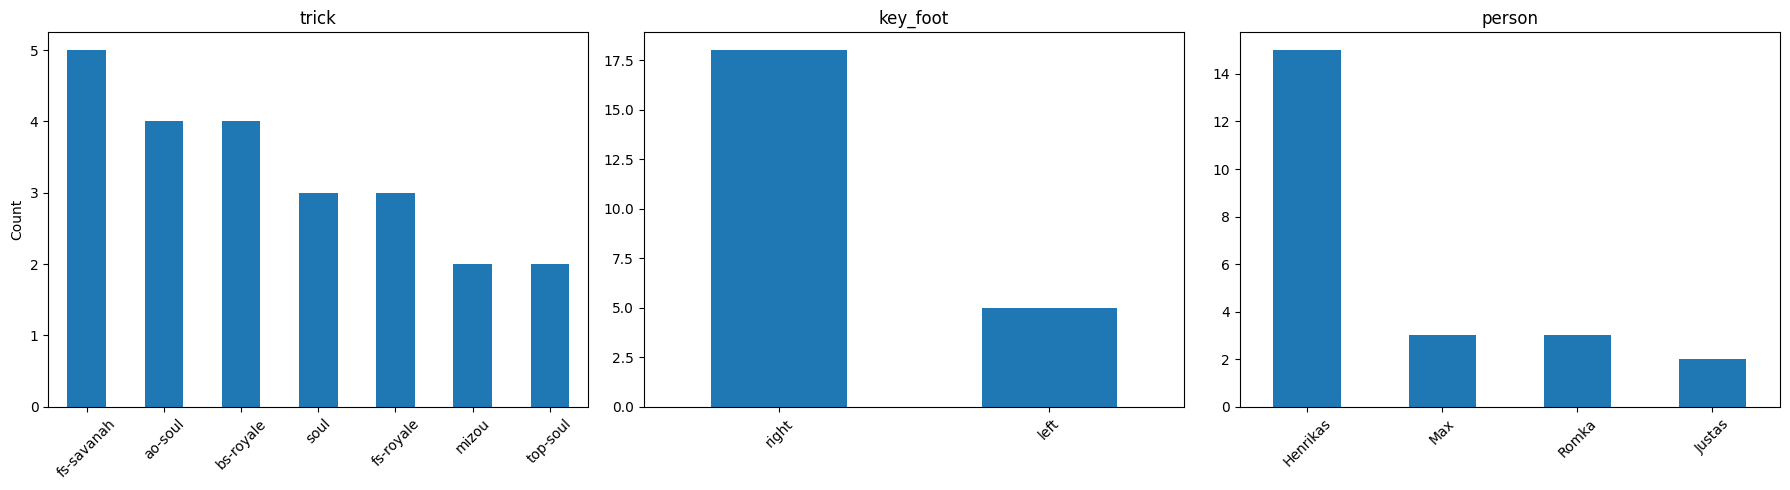

In [8]:
COLS = ["trick", "key_foot", "person"]

fig, axes = plt.subplots(1, len(COLS), figsize=(6 * len(COLS), 5))
axes = np.atleast_1d(axes)

for i, (ax, col) in enumerate(zip(axes, COLS)):
    counts = data[col].value_counts().sort_values(ascending=False)
    counts.plot(kind='bar', ax=ax)
    ax.set_title(col)
    ax.set_xlabel('')
    ax.set_ylabel('Count' if i == 0 else '')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()


#### Create HF dataset

In [9]:
label_names = {
    col: sorted(data[col].dropna().unique().tolist())
    for col in COLS
}

features = ds.Features({
    'video': ds.Video(),
    **{col: ds.ClassLabel(names=label_names[col]) for col in COLS}
})

dataset = ds.Dataset.from_pandas(
    data[['video'] + COLS],
    features=features,
    preserve_index=False
)


#### Test HF dataset

##### Get video from s3 and decode to pixel vals (what we'll feed models)

/home/tufman/src/uni/aitraf/.venv/lib/python3.12/site-packages/fsspec/registry.py:298: UserWarning: Your installed version of s3fs is very old and known to cause
severe performance issues, see also https://github.com/dask/dask/issues/10276

To fix, you should specify a lower version bound on s3fs, or
update the current installation.

  warnings.warn(s3_msg)


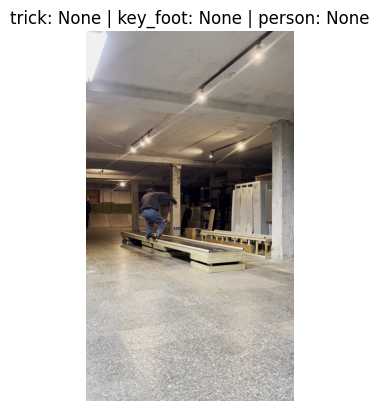

In [10]:
decoded = dataset.cast_column("video", ds.Video(decode=True, dimension_order="NHWC"))
s = decoded[0]
video = np.rot90(s["video"], 3, axes=(1, 2))

labels = []
for c in COLS:
    val = s[c]
    feat = dataset.features[c]
    if isinstance(feat, ds.ClassLabel):
        try:
            val = feat.int2str(val)
        except Exception:
            pass
    labels.append(f"{c}: {val}")

label_text = " | ".join(labels)

frame = video[len(video) // 2]
plt.imshow(frame)
plt.title(label_text)
plt.axis("off")
plt.show()


##### Show video with label (encode it again to show)

In [11]:
with tempfile.NamedTemporaryFile(suffix='.mp4', delete=False) as f:
    tmp = f.name

iio.imwrite(tmp, video, fps=30, codec='libx264', macro_block_size=1)
print(f'Labels: {label_text}')

Video(tmp, embed=True, width=208)


Labels: trick: None | key_foot: None | person: None
